In [62]:
import matplotlib
import pandas as pd
import seaborn as sns
import yaml


with open("../plotting_config.yaml", "r") as fp:
    config = yaml.safe_load(fp)

matplotlib.rcParams["svg.hashsalt"] = "42"
colors=["#bebebe", "#00008b", "#ffa500"]

In [3]:
data = pd.read_csv("../output/regression/allModelFrame_a.csv")

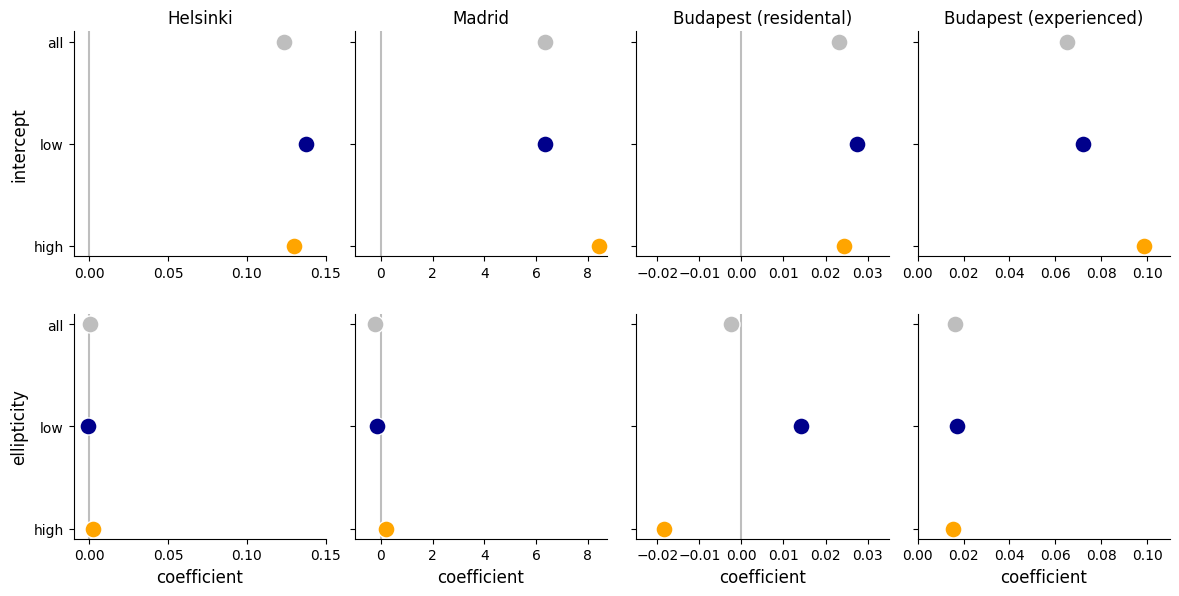

In [63]:
grid = sns.FacetGrid(
    data=data.drop(columns=["std_error", "model"]),
    hue="type",
    col="city",
    row="variable",
    sharex=False,
    hue_order=["all", "low", "high"],
    palette=colors,
)
grid.map(sns.scatterplot, "coef", "type", marker="o", s=150)

for k, ax in grid.axes_dict.items():
    if k[0] == "intercept":
        ax.set_title(k[1])
        ax.set_xlabel("")
    else:
        ax.set_title("")
        ax.set_xlabel("coefficient", fontsize=12)
    ax.set_ylabel(k[0], fontsize=12)
    ax.axvline(0, color="#bebebe", zorder=-10)

for i in ("intercept", "ellipticity"):
    grid.axes_dict[(i, "Helsinki")].set_xlim([-0.01, 0.15])

for i in ("intercept", "ellipticity"):
    grid.axes_dict[(i, "Madrid")].set_xlim([-1, 8.75])

for i in ("intercept", "ellipticity"):
    grid.axes_dict[(i, "Budapest (residental)")].set_xlim([-0.025, 0.035])

for i in ("intercept", "ellipticity"):
    grid.axes_dict[(i, "Budapest (experienced)")].set_xlim([-0, 0.11])

for i in ["png", "svg", "pdf"]:
    grid.savefig(f"../output/figures/coeff_gini_noint.{i}", metadata=config["metadata"][i], bbox_inches="tight")